In [1]:
import torch
from src.evaluator import ShadeEvaluator
from datetime import datetime
import pytz
import pandas as pd

from src.visualization import plot_losses

In [2]:
# Instantiate Evaluator
RESULTS_DIR = "../results/test_ams_100_epoch/"
CHECKPOINT_PATH = "../results/test_ams_100_epoch/checkpoint/checkpoint.ckpt"
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
else "cpu")
print(device)

evaluator = ShadeEvaluator(device, CHECKPOINT_PATH, RESULTS_DIR)

Seed set to 42


mps
Model initialized...


In [4]:
# Test evaluation
test_tile = "/Users/luc/Geomatics/Thesis/misc_data/random/ams_unseen_dsm.tif"
# date_time = datetime.now(pytz.utc)
date_time = datetime(2024, 10, 15, 16, 30, 0, 0)
a = pytz.timezone("Europe/Amsterdam")
date_time = a.localize(date_time, is_dst=False)

evaluator.evaluate(test_tile, date_time, overlap=256, strategy="max")

/Users/luc/Geomatics/Thesis/ShadyShenanigans/src/evaluator.py:88: RuntimeWarning: invalid value encountered in divide
  res = np.divide(out_acc, out_hits, dtype=np.float32)


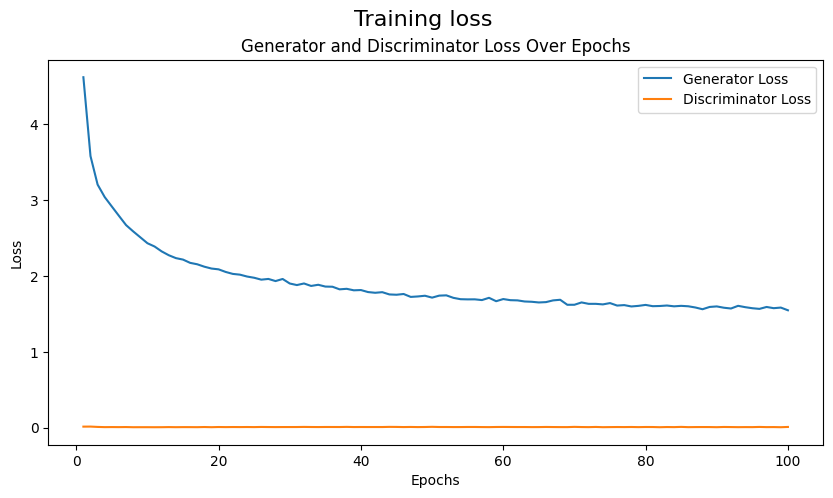

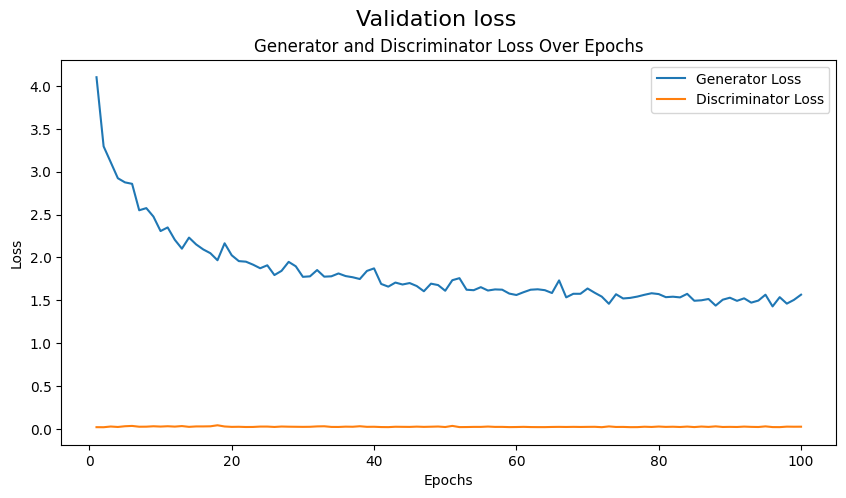

In [2]:
df = pd.read_csv("/Users/luc/Geomatics/Thesis/ShadyShenanigans/results/test_ams_100_epoch/checkpoint/loss_logs/version_0/metrics.csv")

g_train = df["train_g_losses"]
d_train = df["train_d_losses"]
g_val = df["val_g_losses"]
d_val = df["val_d_losses"]

plot_losses(g_train, d_train, title="Training loss")
plot_losses(g_val, d_val, title="Validation loss")